<a href="https://colab.research.google.com/github/luccasnn/limpeza-de-dados/blob/main/limpeza_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Base real de RH IBM + sujeira realista introduzida
url = "https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv"
df_original = pd.read_csv(url)

# Introduz sujeira realista
df_sujo = df_original.copy()
np.random.seed(42)

# Nulos em colunas importantes
idx_nulos = np.random.choice(df_sujo.index, 150, replace=False)
df_sujo.loc[idx_nulos[:50], 'Age'] = np.nan
df_sujo.loc[idx_nulos[50:100], 'MonthlyIncome'] = np.nan
df_sujo.loc[idx_nulos[100:], 'Department'] = np.nan

# Valores impossíveis
df_sujo.loc[np.random.choice(df_sujo.index, 20), 'Age'] = -5
df_sujo.loc[np.random.choice(df_sujo.index, 20), 'MonthlyIncome'] = -999

# Inconsistência de texto
df_sujo['Department'] = df_sujo['Department'].str.replace(
    'Research & Development', 'research & development',
    case=False
).replace({'Sales': 'SALES', 'Human Resources': 'HR'})

# Duplicatas
df_sujo = pd.concat([df_sujo, df_sujo.sample(50)], ignore_index=True)

print("Shape dataset sujo:", df_sujo.shape)
print("\nValores nulos:")
print(df_sujo.isnull().sum()[df_sujo.isnull().sum() > 0])

Shape dataset sujo: (1520, 35)

Valores nulos:
Age              51
Department       54
MonthlyIncome    50
dtype: int64


In [18]:
# Relatório antes da limpeza
print("=== RELATÓRIO DE LIMPEZA ===\n")
print(f"Linhas antes: {len(df_sujo)}")
print(f"Duplicatas encontradas: {df_sujo.duplicated().sum()}")
print(f"Valores negativos em Age: {(df_sujo['Age'] < 0).sum()}")
print(f"Valores negativos em MonthlyIncome: {(df_sujo['MonthlyIncome'] < 0).sum()}")

# 1. Remove duplicatas
df_limpo = df_sujo.drop_duplicates()
print(f"\n✓ Duplicatas removidas: {len(df_sujo) - len(df_limpo)}")

# 2. Remove valores impossíveis
df_limpo = df_limpo[df_limpo['Age'] > 0]
df_limpo = df_limpo[df_limpo['MonthlyIncome'] > 0]
print(f"✓ Valores impossíveis removidos")

# 3. Preenche nulos
df_limpo['Age'] = df_limpo['Age'].fillna(df_limpo['Age'].median())
df_limpo['MonthlyIncome'] = df_limpo['MonthlyIncome'].fillna(df_limpo['MonthlyIncome'].median())
df_limpo['Department'] = df_limpo['Department'].fillna(df_limpo['Department'].mode()[0])
print(f"✓ Nulos preenchidos com mediana/moda")

# 4. Padroniza texto
df_limpo['Department'] = df_limpo['Department'].str.strip().str.title()
print(f"✓ Departamentos padronizados")

print(f"\nLinhas depois: {len(df_limpo)}")
print(f"\nValores nulos restantes:")
print(df_limpo[['Age', 'MonthlyIncome', 'Department']].isnull().sum())

=== RELATÓRIO DE LIMPEZA ===

Linhas antes: 1520
Duplicatas encontradas: 50
Valores negativos em Age: 21
Valores negativos em MonthlyIncome: 21

✓ Duplicatas removidas: 50
✓ Valores impossíveis removidos
✓ Nulos preenchidos com mediana/moda
✓ Departamentos padronizados

Linhas depois: 1332

Valores nulos restantes:
Age              0
MonthlyIncome    0
Department       0
dtype: int64


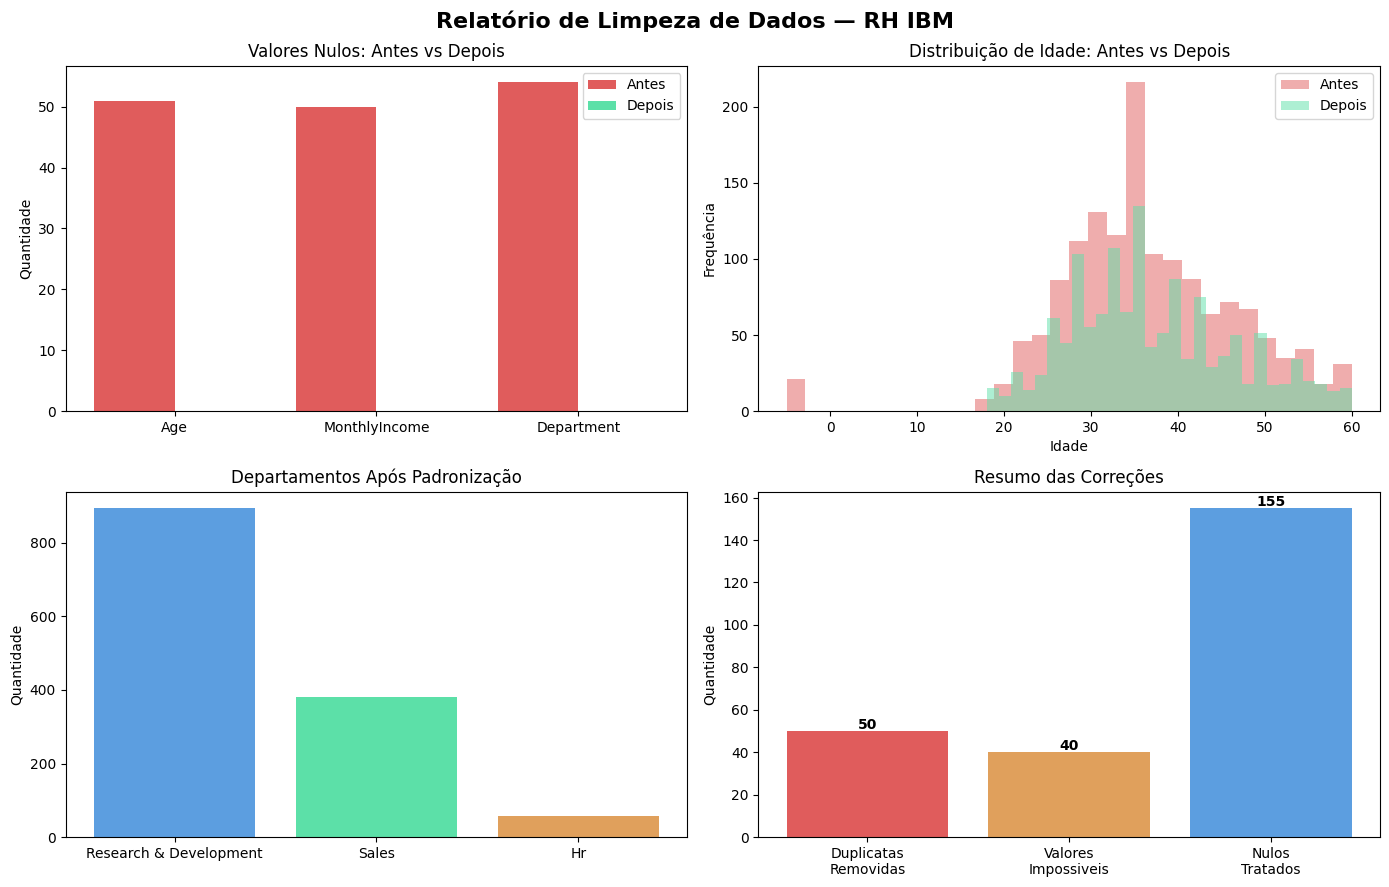

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Relatório de Limpeza de Dados — RH IBM', fontsize=16, fontweight='bold')

# 1. Nulos antes vs depois
colunas = ['Age', 'MonthlyIncome', 'Department']
nulos_antes = [51, 50, 54]
nulos_depois = [0, 0, 0]
x = range(len(colunas))
axes[0, 0].bar([i - 0.2 for i in x], nulos_antes, width=0.4, label='Antes', color='#e05c5c')
axes[0, 0].bar([i + 0.2 for i in x], nulos_depois, width=0.4, label='Depois', color='#5ce0a8')
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(colunas)
axes[0, 0].set_title('Valores Nulos: Antes vs Depois')
axes[0, 0].set_ylabel('Quantidade')
axes[0, 0].legend()

# 2. Distribuição de idade antes vs depois
axes[0, 1].hist(df_sujo['Age'].dropna(), bins=30, alpha=0.5, color='#e05c5c', label='Antes')
axes[0, 1].hist(df_limpo['Age'], bins=30, alpha=0.5, color='#5ce0a8', label='Depois')
axes[0, 1].set_title('Distribuição de Idade: Antes vs Depois')
axes[0, 1].set_xlabel('Idade')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].legend()

# 3. Departamentos padronizados
dept_counts = df_limpo['Department'].value_counts()
axes[1, 0].bar(dept_counts.index, dept_counts.values, color=['#5c9ee0', '#5ce0a8', '#e0a05c'])
axes[1, 0].set_title('Departamentos Após Padronização')
axes[1, 0].set_ylabel('Quantidade')

# 4. Resumo da limpeza
categorias = ['Duplicatas\nRemovidas', 'Valores\nImpossiveis', 'Nulos\nTratados']
valores = [50, 40, 155]
cores = ['#e05c5c', '#e0a05c', '#5c9ee0']
bars = axes[1, 1].bar(categorias, valores, color=cores)
axes[1, 1].set_title('Resumo das Correções')
axes[1, 1].set_ylabel('Quantidade')
for bar, val in zip(bars, valores):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('limpeza_dados.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
df_limpo.to_csv('funcionarios_limpo.csv', index=False)
print("Dataset limpo salvo!")
print(f"Shape final: {df_limpo.shape}")

Dataset limpo salvo!
Shape final: (1332, 35)


In [23]:
from google.colab import files
files.download('limpeza_dados.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>